In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from fastapi import FastAPI
import joblib
import uvicorn
import matplotlib.pyplot as plt
import seaborn as sns
import pickle  

from fastapi.middleware.cors import CORSMiddleware

## 1. Bases

In [2]:
# Carregando os dados para o modelo

properties = pd.read_csv('property_data.csv')
transactions = pd.read_csv('transactions.csv')
economics = pd.read_csv('economics.csv')

## Bases adicionais

mortgage = pd.read_csv('mortgage.csv')
inflation = pd.read_csv('inflation.csv')
rental_vacancy = pd.read_csv('rental_vacancy.csv')

In [3]:
### Inicialmente, observa-se que o property_id das tabelas não correspondem e entregam propriedades diferentes, portanto as bases "properties" e "transactions" não podem ser unidas diretamente. 

In [4]:
### A base de propriedades é a base principal, e será enriquecida posteriormente com possíveis novas variáveis

## 2. Análise exploratória

In [5]:
#### Análise exploratória das variáveis da base de propriedades

In [6]:
properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1000 non-null   int64  
 1   location       1000 non-null   object 
 2   size_sqft      1000 non-null   int64  
 3   bedrooms       1000 non-null   int64  
 4   bathrooms      1000 non-null   int64  
 5   property_id    1000 non-null   int64  
 6   property_type  1000 non-null   object 
 7   property_size  1000 non-null   int64  
 8   year_built     1000 non-null   int64  
 9   listing_price  1000 non-null   float64
 10  num_bedrooms   1000 non-null   int64  
 11  num_bathrooms  1000 non-null   float64
 12  neighborhood   1000 non-null   object 
 13  garage_spaces  1000 non-null   int64  
 14  has_pool       1000 non-null   bool   
dtypes: bool(1), float64(2), int64(9), object(3)
memory usage: 110.5+ KB


In [7]:
## A base não possui valores nulos

properties.isna().sum()

id               0
location         0
size_sqft        0
bedrooms         0
bathrooms        0
property_id      0
property_type    0
property_size    0
year_built       0
listing_price    0
num_bedrooms     0
num_bathrooms    0
neighborhood     0
garage_spaces    0
has_pool         0
dtype: int64

### 2.1 Análise inicial

In [8]:
### Análise inicial estatística das variáveis


## Observa-se certa incongruência entre algumas das variáveis, como por exemplo:

### Variável "size_sqft" difere bastante da variável "property_size"
### Variável "bedrooms" difere bastante da variável "num_bedrooms"
### Variável "bathrooms" difere bastante da variável "num_bathrooms"

## Portanto, serão selecionadas as melhores variáveis segundo a análise exploratória

properties.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1000.0,500.50000,288.819436,1.00,250.750,500.500,750.25,1000.00
size_sqft,1000.0,501.02800,287.186088,1.00,260.750,480.500,750.00,1000.00
bedrooms,1000.0,2.96100,1.401943,1.00,2.000,3.000,4.00,5.00
bathrooms,1000.0,3.50800,1.699065,1.00,2.000,4.000,5.00,6.00
property_id,1000.0,500.50000,288.819436,1.00,250.750,500.500,750.25,1000.00
property_size,1000.0,2760.23000,1319.579978,505.00,1579.500,2792.500,3944.00,4993.00
year_built,1000.0,1962.80700,35.623795,1900.00,1933.750,1963.000,1994.25,2022.00
listing_price,1000.0,544311.87187,258375.306032,100358.27,320294.705,537369.045,764595.35,999759.42
num_bedrooms,1000.0,3.55000,1.732195,1.00,2.000,4.000,5.00,6.00
num_bathrooms,1000.0,2.53400,0.851580,1.00,1.800,2.600,3.20,4.00


### 2.2 Histogramas

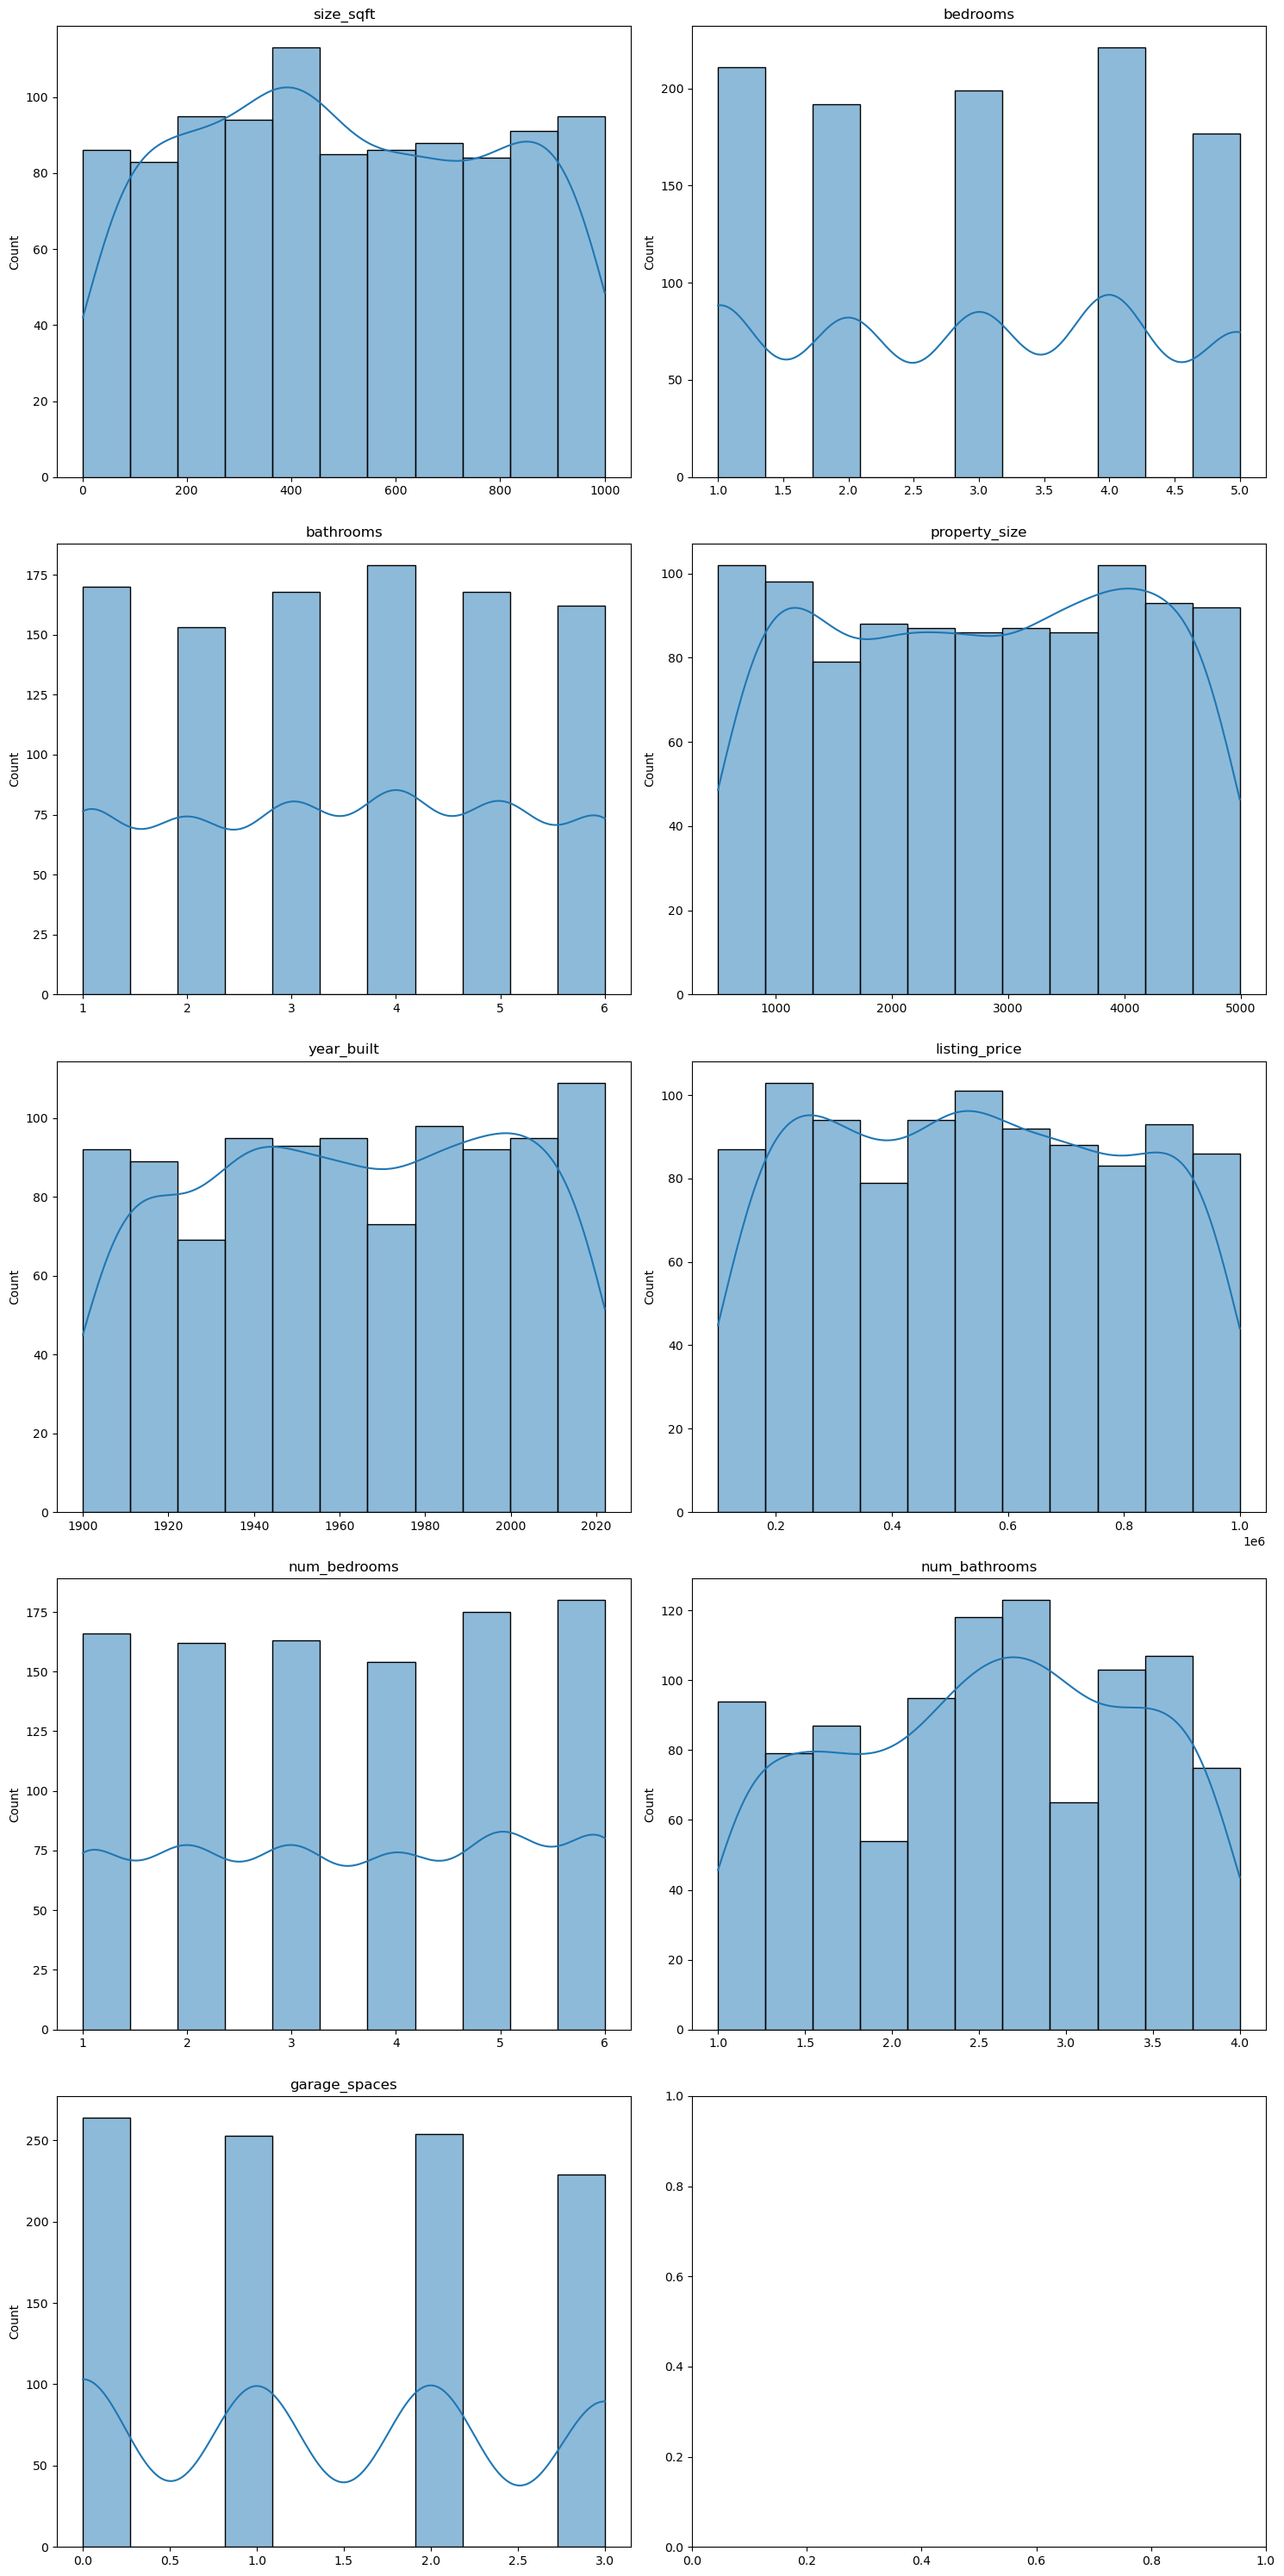

In [9]:
### Plotando os histogramas das variáveis numéricas para embasar o feature selection do modelo

cols = ['size_sqft', 'bedrooms', 'bathrooms',
       'property_size', 'year_built', 'listing_price',
       'num_bedrooms', 'num_bathrooms', 'garage_spaces']

# Ajuste o tamanho da figura e a grade de subplots
fig, axes = plt.subplots(nrows=(len(cols) + 1) // 2, ncols=2, figsize=(15, 30))

for i, col in enumerate(cols):
    sns.histplot(properties[col], kde=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(col)
    axes[i//2, i%2].set_xlabel('')

plt.tight_layout()
plt.show()


### Por esta análise inicial, observa-se distribuições relativamente uniformes. A variável "num_bathrooms" será excluída por não apresentar valores discretos já que a variável deveria ter valores inteiros

### 2.3 Scatter Plot

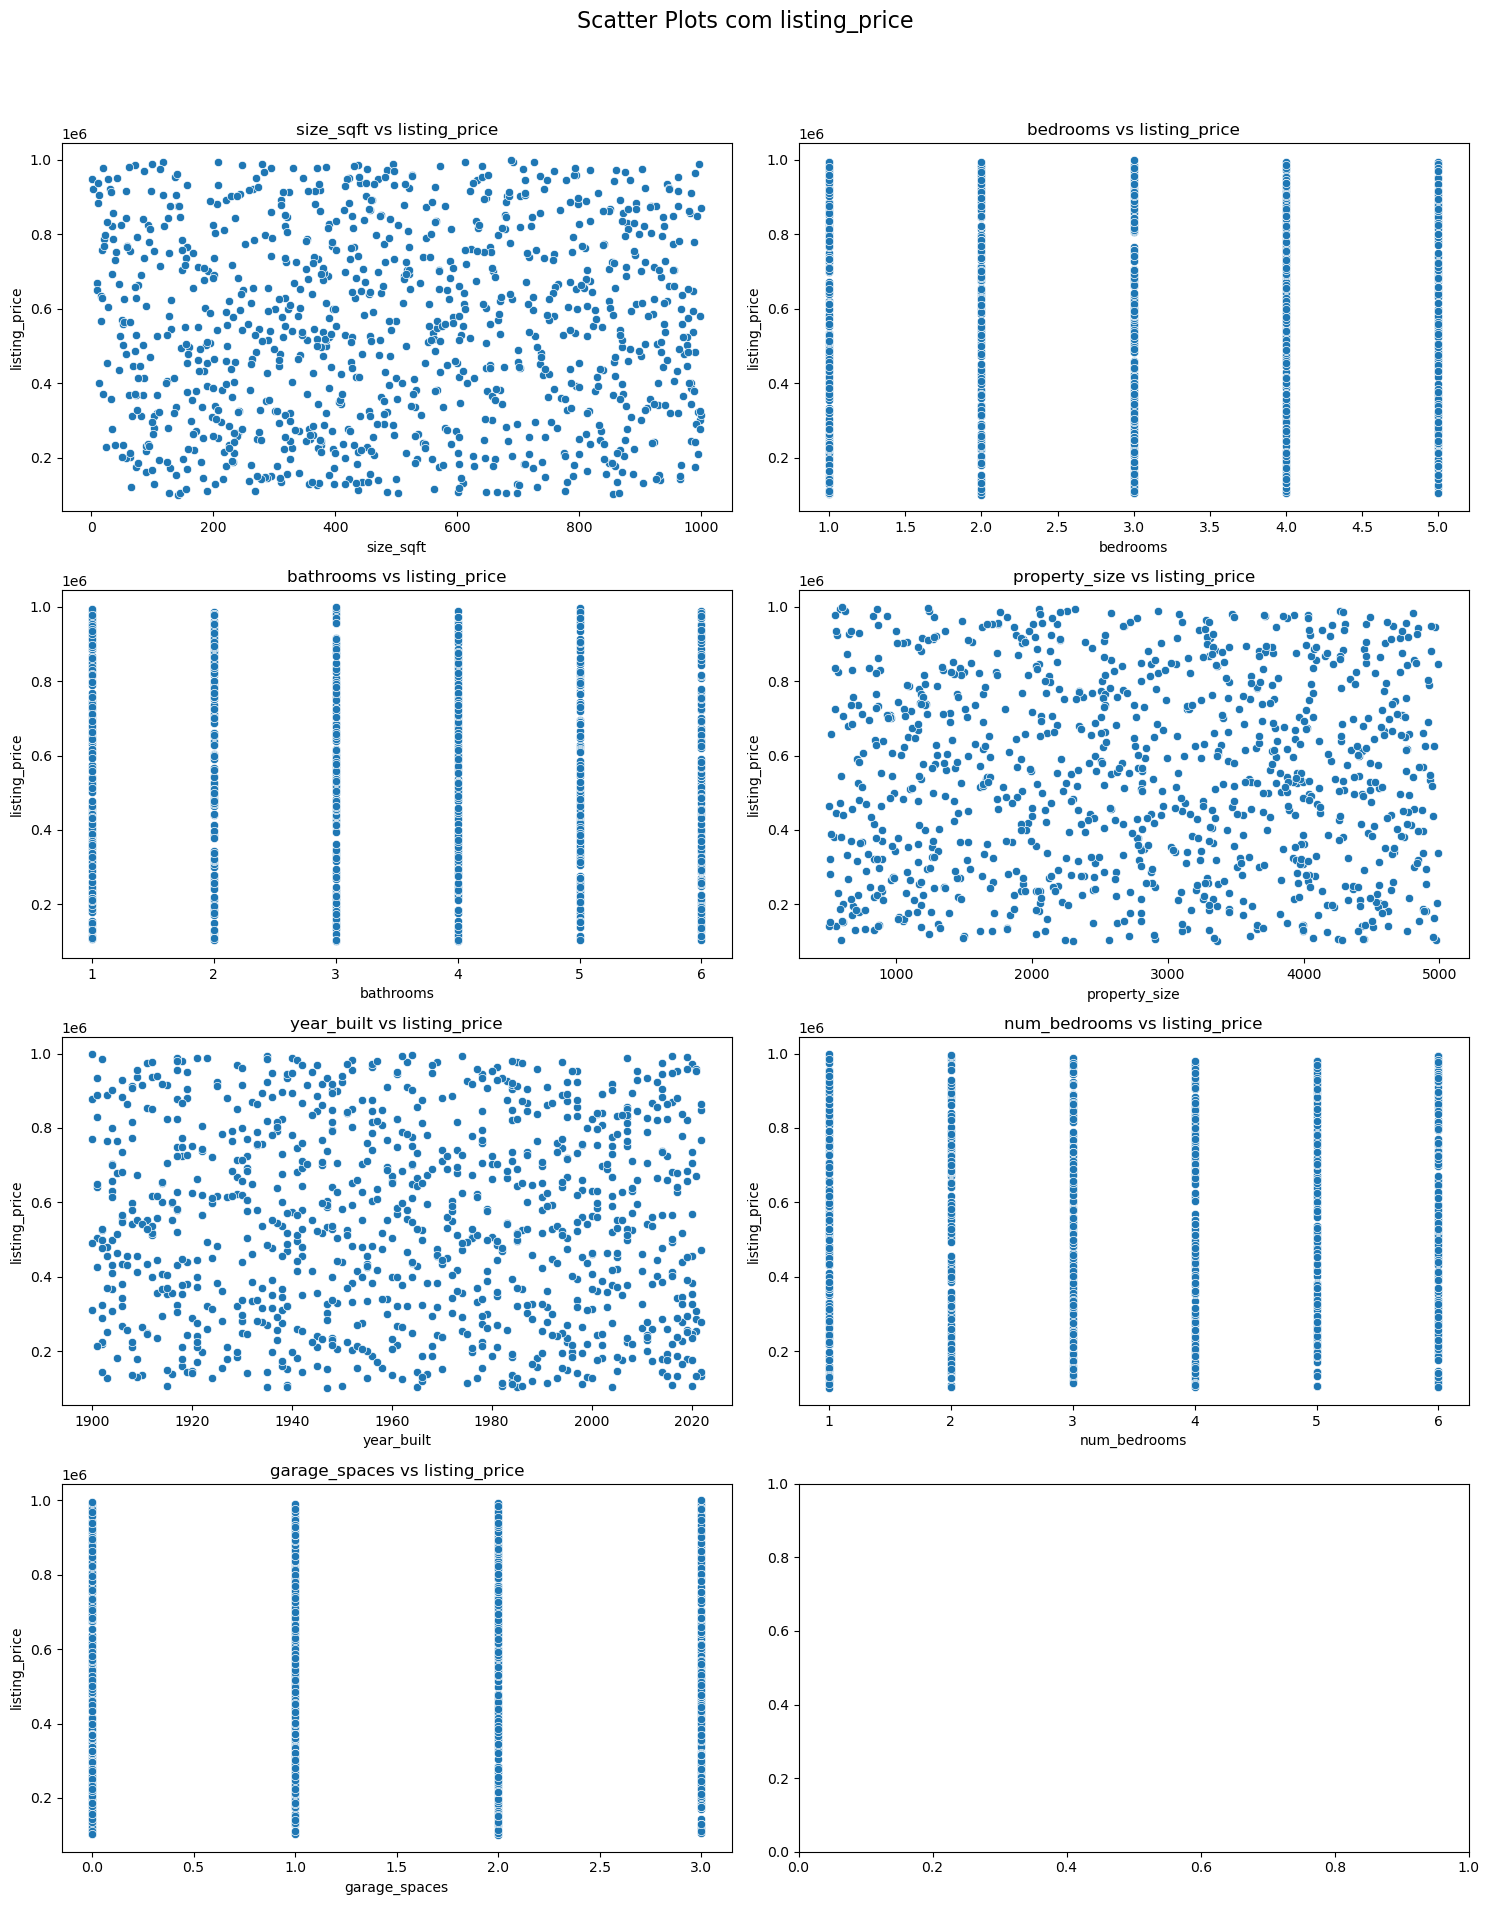

In [10]:
### Como próximo passo será explorada a relação entre as variáveis numéricas e a variável target "listing_price"

## Variáveis analisadas:

var = ['size_sqft', 'bedrooms', 'bathrooms',
       'property_size', 'year_built', 'num_bedrooms', 'garage_spaces']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.suptitle('Scatter Plots com listing_price', fontsize=16)

axes = axes.flatten()

# Gerando scatter plot para cada variável analisada:
for i, col in enumerate(var):
    sns.scatterplot(data=properties, x=col, y='listing_price', ax=axes[i])
    axes[i].set_title(f'{col} vs listing_price')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Não há observação de uma correlação linear entre as variáveis numéricas e a variável target "listing_price"

### 2.4 Matriz de correlação

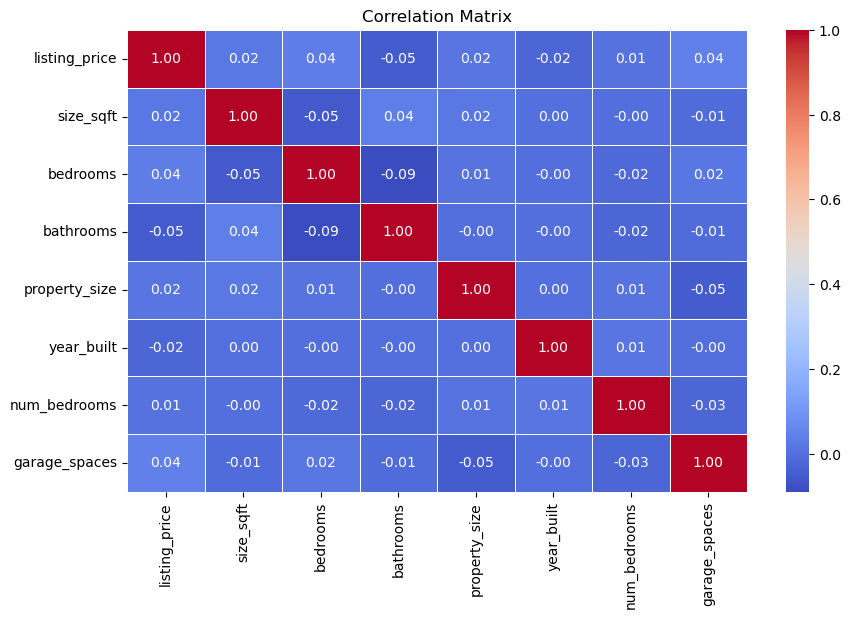

               listing_price  size_sqft  bedrooms  bathrooms  property_size  \
listing_price       1.000000   0.021422  0.037675  -0.049943       0.016310   
size_sqft           0.021422   1.000000 -0.054503   0.038567       0.021343   
bedrooms            0.037675  -0.054503  1.000000  -0.090010       0.010263   
bathrooms          -0.049943   0.038567 -0.090010   1.000000      -0.000895   
property_size       0.016310   0.021343  0.010263  -0.000895       1.000000   
year_built         -0.023490   0.002075 -0.001233  -0.002695       0.003556   
num_bedrooms        0.005543  -0.004180 -0.017127  -0.021903       0.012019   
garage_spaces       0.044824  -0.009325  0.019582  -0.012505      -0.049649   

               year_built  num_bedrooms  garage_spaces  
listing_price   -0.023490      0.005543       0.044824  
size_sqft        0.002075     -0.004180      -0.009325  
bedrooms        -0.001233     -0.017127       0.019582  
bathrooms       -0.002695     -0.021903      -0.012505  
pro

In [11]:
### Agora, realizaremos a análise de corelação para quantificar o relacionamento entre as variáveis

var = ['listing_price','size_sqft', 'bedrooms', 'bathrooms',
       'property_size', 'year_built', 'num_bedrooms', 'garage_spaces']


# Correlation matrix
correlation_matrix = properties[var].corr()

# Potando a matriz de correlações
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

print(correlation_matrix)


### Dentre as variáveis disponíveis, não se encontram variáveis com grande correlação com o preço listado das propriedades

## 3. Seleção e engenharia de variáveis

### 3.1 Seleção das variáveis da base de propriedades

In [12]:
### Selecionando as variáveis dentro da base de propriedades

## Variáveis escolhidas segundo a análise exploratória:

var_modelo = ['property_id', 'bedrooms', 'bathrooms', 
       'property_type', 'property_size', 'year_built', 'listing_price',
       'neighborhood', 'garage_spaces',
       'has_pool']

properties_modelo = properties[var_modelo]  

### A variável de localização será desconsiderada deste modelo inicial por adicionar complexidade e não possuir grande correlação com o valor de venda

## 4. Construção do modelo


#### Será construído um modelo baseado na base de propriedades que dirá um valor razoável de pedida de venda


In [13]:

### Separando a base entre treino e teste

X = properties_modelo.drop(columns=['listing_price'])
y = properties_modelo['listing_price']

# Criar variáveis dummies para todas as colunas categóricas
X = pd.get_dummies(X, drop_first=True)

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:

# Inicializar os modelos
model = LinearRegression()
model_RF = RandomForestRegressor()
model_XGB = XGBRegressor()

# Treinar os modelos
model.fit(X_train, y_train)
model_RF.fit(X_train, y_train)
model_XGB.fit(X_train, y_train)

# Lista de modelos
models = [model, model_RF, model_XGB]
model_names = ['Linear Regression', 'Random Forest', 'XGBoost']

# Avaliar a performance dos modelos
for i in range(len(models)):
    print(f'{model_names[i]}:')
    
    # Previsões
    y_train_pred = models[i].predict(X_train)
    y_test_pred = models[i].predict(X_test)

    # Métricas de performance
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    mse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Exibir as métricas
    print('Training MSE:', mse_train)
    print('Validation MSE:', mse_test)
    print('Training MAE:', mae_train)
    print('Validation MAE:', mae_test)
    print('Training R²:', r2_train)
    print('Validation R²:', r2_test)
    print()

Linear Regression:
Training MSE: 66499462341.08616
Validation MSE: 63835110215.173065
Training MAE: 222318.41270882846
Validation MAE: 216455.34825638362
Training R²: 0.012947637226926378
Validation R²: -0.003437925695565891

Random Forest:
Training MSE: 10293331689.429699
Validation MSE: 67058722837.04929
Training MAE: 85789.65848512504
Validation MAE: 217725.56804299995
Training R²: 0.8472159472095276
Validation R²: -0.05411059081101932

XGBoost:
Training MSE: 209274049.1949839
Validation MSE: 79886483799.71942
Training MAE: 10123.407566796874
Validation MAE: 230986.9413234375
Training R²: 0.9968937426341059
Validation R²: -0.25575294418539696



In [ ]:
### Análise das Métricas:

# Validation MSE (Mean Squared Error): Quanto menor, melhor
# Linear Regression tem o menor Validation MSE (63,835,110,215.17).

# Validation MAE (Mean Absolute Error): Quanto menor, melhor
# Linear Regression tem o menor Validation MAE (216,455.35).

# Validation R² (R-squared): Quanto maior, melhor
# Linear Regression tem o maior Validation R² (-0.0034), embora todos os modelos tenham valores negativos, ou seja, nenhum modelo está com performance boa

### Conclusão:
# Com base nas métricas de validação, Linear Regression teve a melhor performance relativa, pois possui o menor Validation MSE e Validation MAE, e o maior (menos negativo) Validation R². No entanto, é importante notar que todos os modelos têm um desempenho ruim, com R² negativos, indicando que não capturam bem a variabilidade dos dados e portanto sugere que pode haver problemas com os dados ou que os modelos necessitam de ajustes adicionais

### 5. Construção da API para utilização dos modelos construídos

In [33]:
### Salvando os modelos treinados

pickle.dump(model, open("model.pkl", "wb"))

In [34]:
import pandas as pd
import pickle
from flask import Flask, request, jsonify

# Create a Flask app
app = Flask(__name__)

# Load the machine learning model from a pickle file
model = pickle.load(open("model.pkl", "rb"))

@app.route('/keepalive', methods=['GET'])
def api_health():
    return jsonify(Message="Success")

# Define a route for making predictions
@app.route("/predict", methods=["POST"])
def predict():
    # Get JSON data from the request
    json_ = request.json

    # Convert JSON data into a DataFrame
    df = pd.DataFrame(json_)

    # Use the loaded model to make predictions on the DataFrame
    prediction = model.predict(df)

    # Return the predictions as a JSON response
    return jsonify({"Prediction": list(prediction)})

# Run the Flask app when this script is executed
if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1